In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:

df = pd.read_csv("../data/processed_customer_churn.csv")
print(df.shape)
df.head()

(7043, 30)


,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Churn,Age,Married,Number of Dependents,Satisfaction Score,CLTV,Churn Category,Churn Reason,Zip Code,Population
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,36,Yes,0,3,3964,NaN,NaN,90001,54492
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,No,46,No,0,3,3441,NaN,NaN,90002,44586
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,Yes,37,No,0,1,3239,Competitor,Competitor made better offer,90003,58198
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,No,53,No,0,3,4307,NaN,NaN,90004,67852
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,Yes,19,No,2,2,2701,Other,Moved,90005,43019


# Contract type vs Churn

In [5]:
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x:(x=='Yes').mean()*100).round(1)
contract_churn = contract_churn.sort_values(ascending = False)
print(contract_churn)

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


/var/folders/g6/9sy6mfks2wbcrs9l17dfmkt40000gq/T/ipykernel_3931/3664574394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index , y=contract_churn.values,palette='Blues_r')


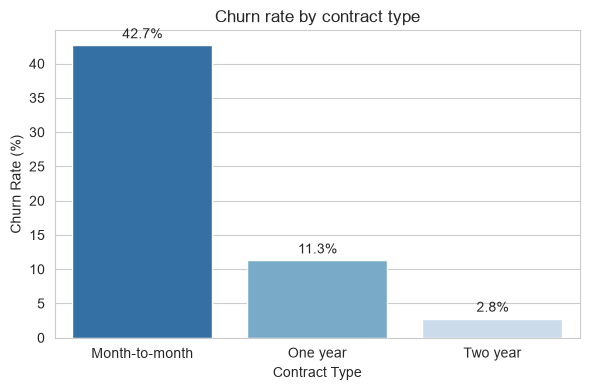

In [6]:
plt.figure(figsize=(6,4))
sns.barplot(x=contract_churn.index , y=contract_churn.values,palette='Blues_r')
plt.title('Churn rate by contract type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
for i ,v in enumerate(contract_churn.values):
    plt.text(i,v+1,f'{v}%',ha ='center')
plt.tight_layout()
plt.savefig('../notebooks/charts_h1_contract_churn.png', dpi=150)
plt.show()

  # — churn rate by payment method
  

In [10]:
df.groupby('Payment Method')['Churn'].apply(lambda x:(x== 'Yes').mean()*100).round(1)

Payment Method
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64

In [12]:
payment_churn = df.groupby('Payment Method')['Churn'].apply(lambda x:(x== 'Yes').mean()*100).round(1)
payment_churn = payment_churn.sort_values(ascending = False)
print(payment_churn)

Payment Method
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


/var/folders/g6/9sy6mfks2wbcrs9l17dfmkt40000gq/T/ipykernel_3931/2566941948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = payment_churn.index,y = payment_churn.values,palette='Reds_r')


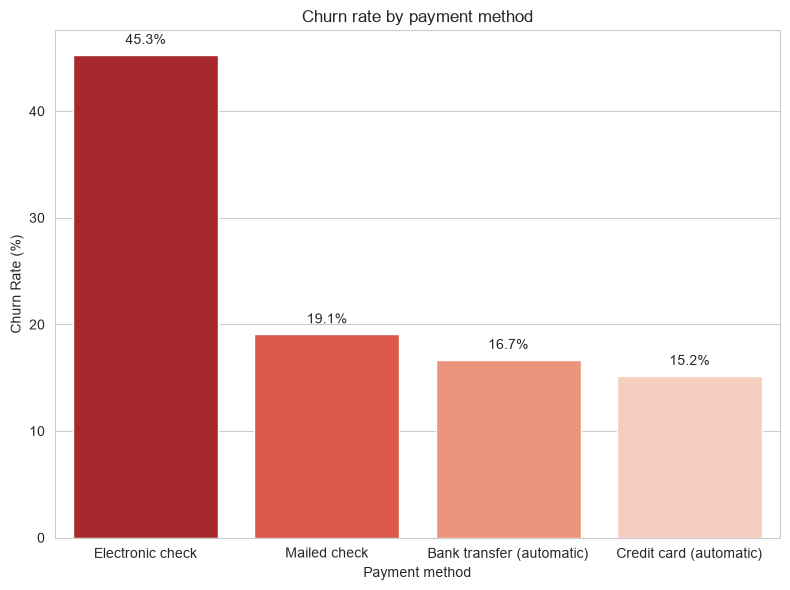

In [18]:
plt.figure(figsize =(8,6))
sns.barplot(x = payment_churn.index,y = payment_churn.values,palette='Reds_r')
plt.title('Churn rate by payment method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment method')
for i ,v in enumerate(payment_churn.values):
    plt.text(i,v+1,f'{v}%',ha ='center')
plt.tight_layout()
plt.savefig('../notebooks/charts_h1_contract_churn.png', dpi=150)
plt.show()            
            

#  Average tenure by churn status

In [19]:
df.groupby('Churn')['Tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: Tenure, dtype: float64

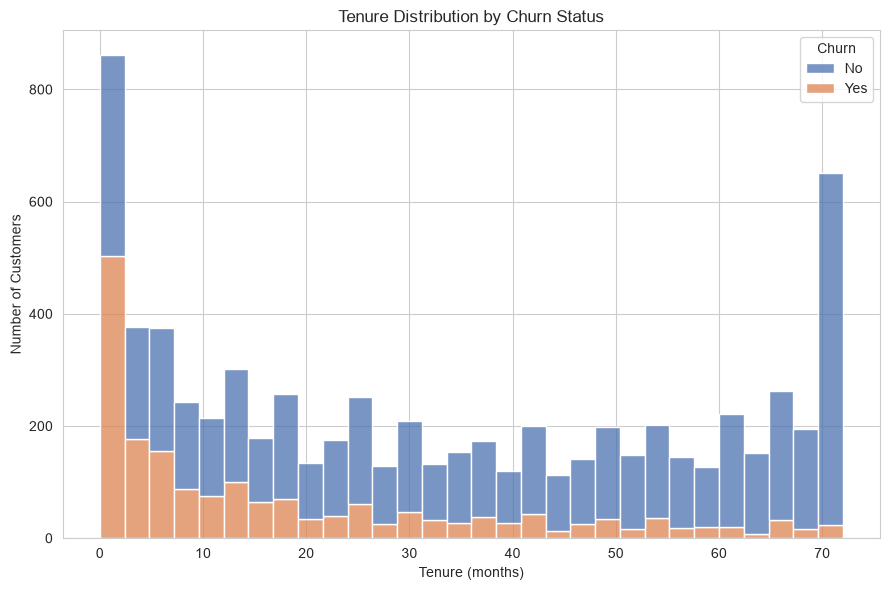

In [23]:

plt.figure(figsize=(9,6))
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30, multiple='stack', palette=['#4C72B0', '#DD8452'])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../notebooks/charts_h3_tenure_churn.png', dpi=150)
plt.show()

# Churn rate by Tech Support 

In [27]:
df.groupby('Tech Support')['Churn'].apply(lambda x:(x== 'Yes').mean()*100).round(1)

Tech Support
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64

In [28]:
# "No internet service" really its own low-churn segment, or noise?
df[df['Tech Support'] == 'No internet service']['Internet Service'].unique()

<StringArray>
['No']
Length: 1, dtype: str

In [29]:
# churn rate by Tech Support, restricted to customers who HAVE internet
has_internet = df[df['Internet Service'] != 'No']

tech_support_churn = has_internet.groupby('Tech Support')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(tech_support_churn)

Tech Support
No     41.6
Yes    15.2
Name: Churn, dtype: float64


/var/folders/g6/9sy6mfks2wbcrs9l17dfmkt40000gq/T/ipykernel_3931/3306237443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tech_support_churn.index, y=tech_support_churn.values, palette='Purples_r')


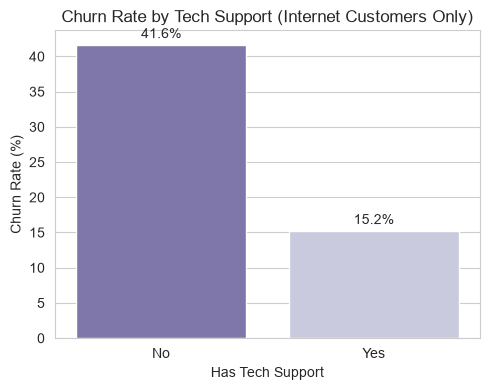

In [30]:

plt.figure(figsize=(5,4))
sns.barplot(x=tech_support_churn.index, y=tech_support_churn.values, palette='Purples_r')
plt.title('Churn Rate by Tech Support (Internet Customers Only)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Has Tech Support')
for i, v in enumerate(tech_support_churn.values):
    plt.text(i, v + 1, f'{v}%', ha='center')
plt.tight_layout()
plt.savefig('../notebooks/charts_h4_tech_support_churn.png', dpi=150)
plt.show()

In [31]:
#  churn rate by Online Security, restricted to customers who HAVE internet
online_security_churn = has_internet.groupby('Online Security')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(online_security_churn)

Online Security
No     41.8
Yes    14.6
Name: Churn, dtype: float64


/var/folders/g6/9sy6mfks2wbcrs9l17dfmkt40000gq/T/ipykernel_3931/2115749850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=online_security_churn.index, y=online_security_churn.values, palette='Greens_r')


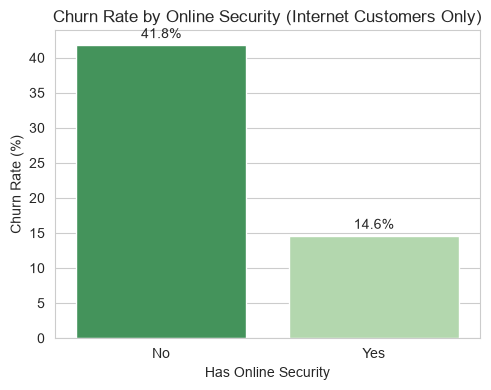

In [32]:

plt.figure(figsize=(5,4))
sns.barplot(x=online_security_churn.index, y=online_security_churn.values, palette='Greens_r')
plt.title('Churn Rate by Online Security (Internet Customers Only)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Has Online Security')
for i, v in enumerate(online_security_churn.values):
    plt.text(i, v + 1, f'{v}%', ha='center')
plt.tight_layout()
plt.savefig('../notebooks/charts_h4b_online_security_churn.png', dpi=150)
plt.show()

# Monlthy charges vs churn

/var/folders/g6/9sy6mfks2wbcrs9l17dfmkt40000gq/T/ipykernel_3931/4104316759.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly Charges', palette=['#4C72B0', '#DD8452'])


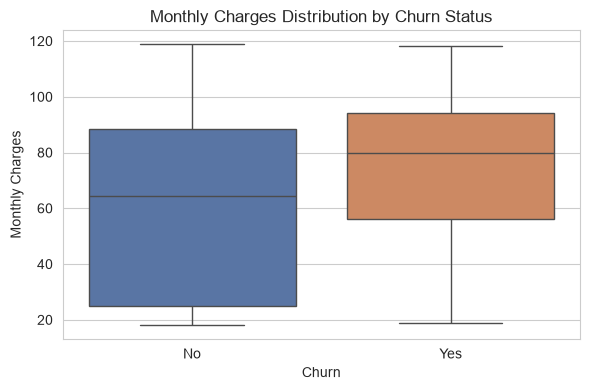

In [33]:

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='Monthly Charges', palette=['#4C72B0', '#DD8452'])
plt.title('Monthly Charges Distribution by Churn Status')
plt.tight_layout()
plt.savefig('../notebooks/charts_h5_monthlycharges_boxplot.png', dpi=150)
plt.show()

# Correlation matrix

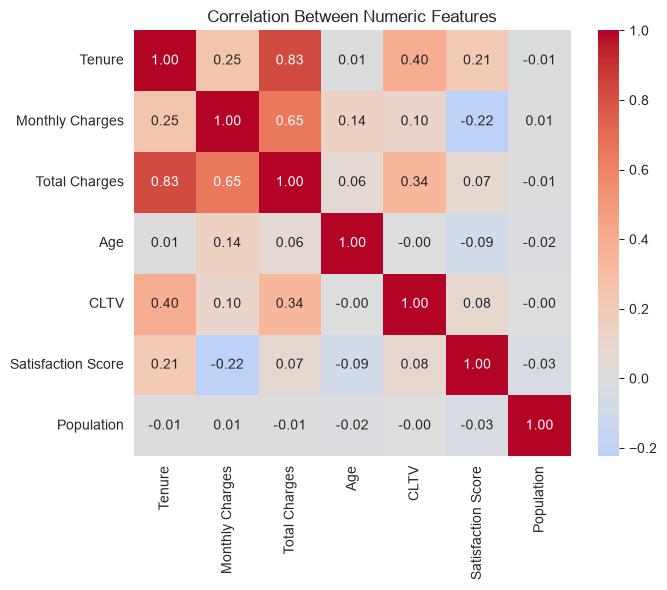

In [35]:

numeric_cols = ['Tenure', 'Monthly Charges', 'Total Charges', 'Age', 'CLTV', 'Satisfaction Score', 'Population']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.savefig('../notebooks/charts_h6_correlation_heatmap.png', dpi=150)
plt.show()

# Satisfaction Score vs Churn directly

In [36]:

satisfaction_churn = df.groupby('Satisfaction Score')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(satisfaction_churn)

Satisfaction Score
1    100.0
2    100.0
3     16.1
4      0.0
5      0.0
Name: Churn, dtype: float64


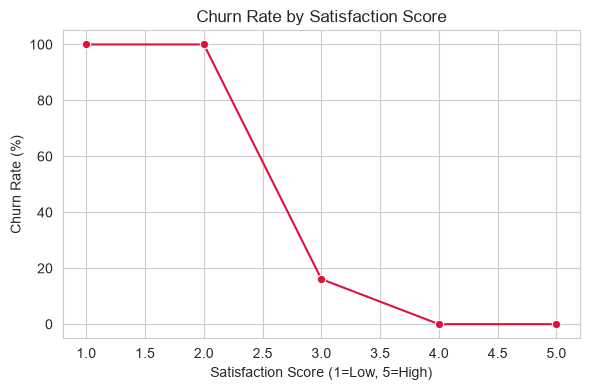

In [37]:

plt.figure(figsize=(6,4))
sns.lineplot(x=satisfaction_churn.index, y=satisfaction_churn.values, marker='o', color='crimson')
plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score (1=Low, 5=High)')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../notebooks/charts_h7_satisfaction_churn.png', dpi=150)
plt.show()

In [38]:

df.groupby('Churn')['Satisfaction Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,3.789911,0.781162,3.0,3.0,4.0,4.0,5.0
Yes,1869.0,1.736223,0.808466,1.0,1.0,2.0,2.0,3.0


In [39]:

df.groupby('Churn')['CLTV'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
Yes,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0
